# TF Pairs Dataset Integration

This notebook compares the TF cluster assignments and top TF-TF correlation pairs from the DOGMA and Jurgens analyses. The goal is to quantify how much the two datasets agree at three levels:

1. TF coverage across datasets.
2. TF cluster membership and cluster-to-cluster correspondence.
3. TF-pair correlation rankings and effect sizes.

The figures below are designed to make agreement and disagreement easy to spot quickly.

In [1]:
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

## Load and Harmonize Inputs

In [2]:
def resolve_tf_pairs_dir() -> Path:
    candidates = [
        Path.cwd(),
        Path.cwd() / 'TF_pairs',
        Path.cwd().parent / 'TF_pairs',
    ]
    required_names = {
        'tf_cluster_assignments_dogma.txt',
        'tf_cluster_assignments_dogma.csv',
        'tf_cluster_assignments_jurgens.txt',
        'tf_cluster_assignments_jurgens.csv',
    }
    for candidate in candidates:
        if any((candidate / name).exists() for name in required_names):
            return candidate
    raise FileNotFoundError(
        'Could not locate the TF_pairs directory from the current working directory. '
        f'Tried: {candidates}'
    )


def resolve_existing_file(base: Path, candidates: list[str]) -> Path:
    for name in candidates:
        path = base / name
        if path.exists():
            return path
    raise FileNotFoundError(f'Could not find any of these files in {base}: {candidates}')


BASE = resolve_tf_pairs_dir()

DOGMA_ASSIGN_PATH = resolve_existing_file(BASE, ['tf_cluster_assignments_dogma.txt', 'tf_cluster_assignments_dogma.csv'])
JURGENS_ASSIGN_PATH = resolve_existing_file(BASE, ['tf_cluster_assignments_jurgens.txt', 'tf_cluster_assignments_jurgens.csv'])
DOGMA_PAIRS_PATH = resolve_existing_file(BASE, ['top_tf_pairs_logFC_dogma.csv', 'top_tf_pairs_logFC_DOGMA.csv'])
JURGENS_PAIRS_PATH = resolve_existing_file(BASE, ['top_tf_pairs_logFC_jurgens.csv', 'top_tf_pairs_logFC_JURGENS.csv'])


def load_assignment_table(path: Path, dataset_name: str) -> pd.DataFrame:
    sep = '\t' if path.suffix.lower() == '.txt' else ','
    df = pd.read_csv(path, sep=sep)

    rename_map = {
        'TF_cluster': 'cluster',
        'Cluster': 'cluster',
    }
    df = df.rename(columns=rename_map)

    required_cols = {'cluster', 'TF'}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f'{path.name} is missing required columns: {sorted(missing)}')

    df['dataset'] = dataset_name
    if 'UMAP1' not in df.columns:
        df['UMAP1'] = np.nan
    if 'UMAP2' not in df.columns:
        df['UMAP2'] = np.nan

    return df[['dataset', 'cluster', 'TF', 'UMAP1', 'UMAP2']].copy()


def canonical_pair_key(tf1: str, tf2: str) -> str:
    return '__'.join(sorted((tf1, tf2)))


def load_pair_table(path: Path, dataset_name: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    df['dataset'] = dataset_name
    df['pair_key'] = df.apply(lambda row: canonical_pair_key(row['TF1'], row['TF2']), axis=1)
    df['pair_label'] = df.apply(lambda row: ' / '.join(sorted((row['TF1'], row['TF2']))), axis=1)
    df['rank'] = np.arange(1, len(df) + 1)
    return df


dogma_assign = load_assignment_table(DOGMA_ASSIGN_PATH, 'DOGMA')
jurgens_assign = load_assignment_table(JURGENS_ASSIGN_PATH, 'Jurgens')
dogma_pairs = load_pair_table(DOGMA_PAIRS_PATH, 'DOGMA')
jurgens_pairs = load_pair_table(JURGENS_PAIRS_PATH, 'Jurgens')

shared_tfs = sorted(set(dogma_assign['TF']) & set(jurgens_assign['TF']))
dogma_only_tfs = sorted(set(dogma_assign['TF']) - set(jurgens_assign['TF']))
jurgens_only_tfs = sorted(set(jurgens_assign['TF']) - set(dogma_assign['TF']))

shared_pairs = sorted(set(dogma_pairs['pair_key']) & set(jurgens_pairs['pair_key']))

print(f'DOGMA TFs: {dogma_assign.TF.nunique()}')
print(f'Jurgens TFs: {jurgens_assign.TF.nunique()}')
print(f'Shared TFs: {len(shared_tfs)}')
print(f'DOGMA-only TFs: {len(dogma_only_tfs)}')
print(f'Jurgens-only TFs: {len(jurgens_only_tfs)}')
print(f'Shared TF pairs among the top-ranked tables: {len(shared_pairs)}')

DOGMA TFs: 57
Jurgens TFs: 64
Shared TFs: 57
DOGMA-only TFs: 0
Jurgens-only TFs: 7
Shared TF pairs among the top-ranked tables: 39


## Dataset Overview

In [3]:
overview = pd.DataFrame([
    {
        'dataset': 'DOGMA',
        'n_clusters': dogma_assign['cluster'].nunique(),
        'n_tfs': dogma_assign['TF'].nunique(),
        'n_top_pairs': len(dogma_pairs),
    },
    {
        'dataset': 'Jurgens',
        'n_clusters': jurgens_assign['cluster'].nunique(),
        'n_tfs': jurgens_assign['TF'].nunique(),
        'n_top_pairs': len(jurgens_pairs),
    },
])

overview

,dataset,n_clusters,n_tfs,n_top_pairs
0,DOGMA,6,57,200
1,Jurgens,6,64,200


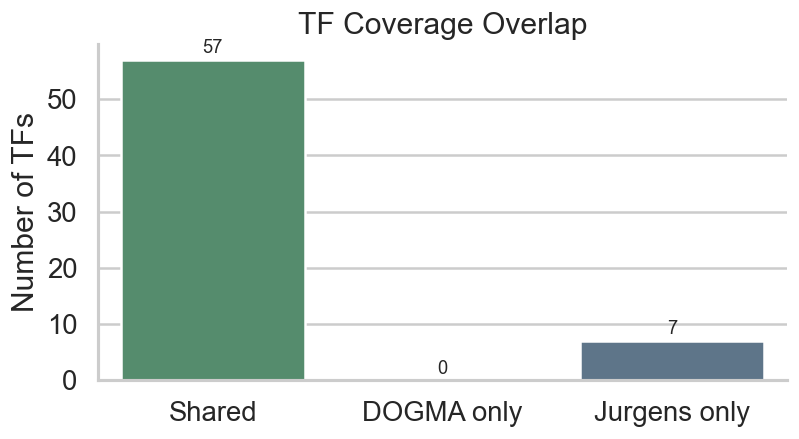

,DOGMA_only,Jurgens_only
0,NaN,HDAC6
1,NaN,IRF4
2,NaN,MYB
3,NaN,MYC
4,NaN,SOX4
5,NaN,TOX2
6,NaN,TRIM21


In [4]:
tf_overlap_summary = pd.DataFrame({
    'group': ['Shared', 'DOGMA only', 'Jurgens only'],
    'count': [len(shared_tfs), len(dogma_only_tfs), len(jurgens_only_tfs)],
})

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(
    data=tf_overlap_summary,
    x='group',
    y='count',
    hue='group',
    palette=['#4C956C', '#D97D54', '#577590'],
    dodge=False,
    legend=False,
    ax=ax,
)
ax.set_title('TF Coverage Overlap')
ax.set_xlabel('')
ax.set_ylabel('Number of TFs')
for patch in ax.patches:
    ax.text(
        patch.get_x() + patch.get_width() / 2,
        patch.get_height() + 0.5,
        f"{int(patch.get_height())}",
        ha='center',
        va='bottom',
        fontsize=11,
    )
plt.tight_layout()
plt.show()

pd.DataFrame({
    'DOGMA_only': pd.Series(dogma_only_tfs),
    'Jurgens_only': pd.Series(jurgens_only_tfs),
})

## Cluster Membership Concordance

In [5]:
dogma_shared = dogma_assign[dogma_assign['TF'].isin(shared_tfs)].copy()
jurgens_shared = jurgens_assign[jurgens_assign['TF'].isin(shared_tfs)].copy()

cluster_overlap_records = []
for dogma_cluster, jurgens_cluster in product(sorted(dogma_shared['cluster'].unique()), sorted(jurgens_shared['cluster'].unique())):
    dogma_members = set(dogma_shared.loc[dogma_shared['cluster'] == dogma_cluster, 'TF'])
    jurgens_members = set(jurgens_shared.loc[jurgens_shared['cluster'] == jurgens_cluster, 'TF'])
    intersection = dogma_members & jurgens_members
    union = dogma_members | jurgens_members
    cluster_overlap_records.append({
        'dogma_cluster': dogma_cluster,
        'jurgens_cluster': jurgens_cluster,
        'shared_tfs': len(intersection),
        'jaccard': len(intersection) / len(union) if union else np.nan,
        'shared_tf_list': ', '.join(sorted(intersection)),
    })

cluster_overlap = pd.DataFrame(cluster_overlap_records)
shared_count_matrix = cluster_overlap.pivot(index='dogma_cluster', columns='jurgens_cluster', values='shared_tfs')
jaccard_matrix = cluster_overlap.pivot(index='dogma_cluster', columns='jurgens_cluster', values='jaccard')

best_matches = (
    cluster_overlap.sort_values(['dogma_cluster', 'jaccard', 'shared_tfs'], ascending=[True, False, False])
    .groupby('dogma_cluster', as_index=False)
    .first()
    .rename(columns={'jurgens_cluster': 'best_jurgens_cluster'})
)

best_matches[['dogma_cluster', 'best_jurgens_cluster', 'shared_tfs', 'jaccard', 'shared_tf_list']]

,dogma_cluster,best_jurgens_cluster,shared_tfs,jaccard,shared_tf_list
0,0,0,8,0.533333,"BCL2, DNMT3A, ETS1, IKZF1, IRF9, KLHL22, PIM2,..."
1,1,1,7,0.500000,"BATF, EOMES, HAVCR2, HDAC1, IKZF3, NFATC3, RUNX1"
2,2,5,5,0.416667,"FOS, JUN, KLF7, LEF1, TCF7"
3,3,2,4,0.235294,"CREM, NR4A2, NR4A3, STAT3"
4,4,4,4,0.333333,"BRD4, EZH2, MDM2, NFATC2"
5,5,2,3,0.200000,"BHLHE40, RUNX3, ZEB2"


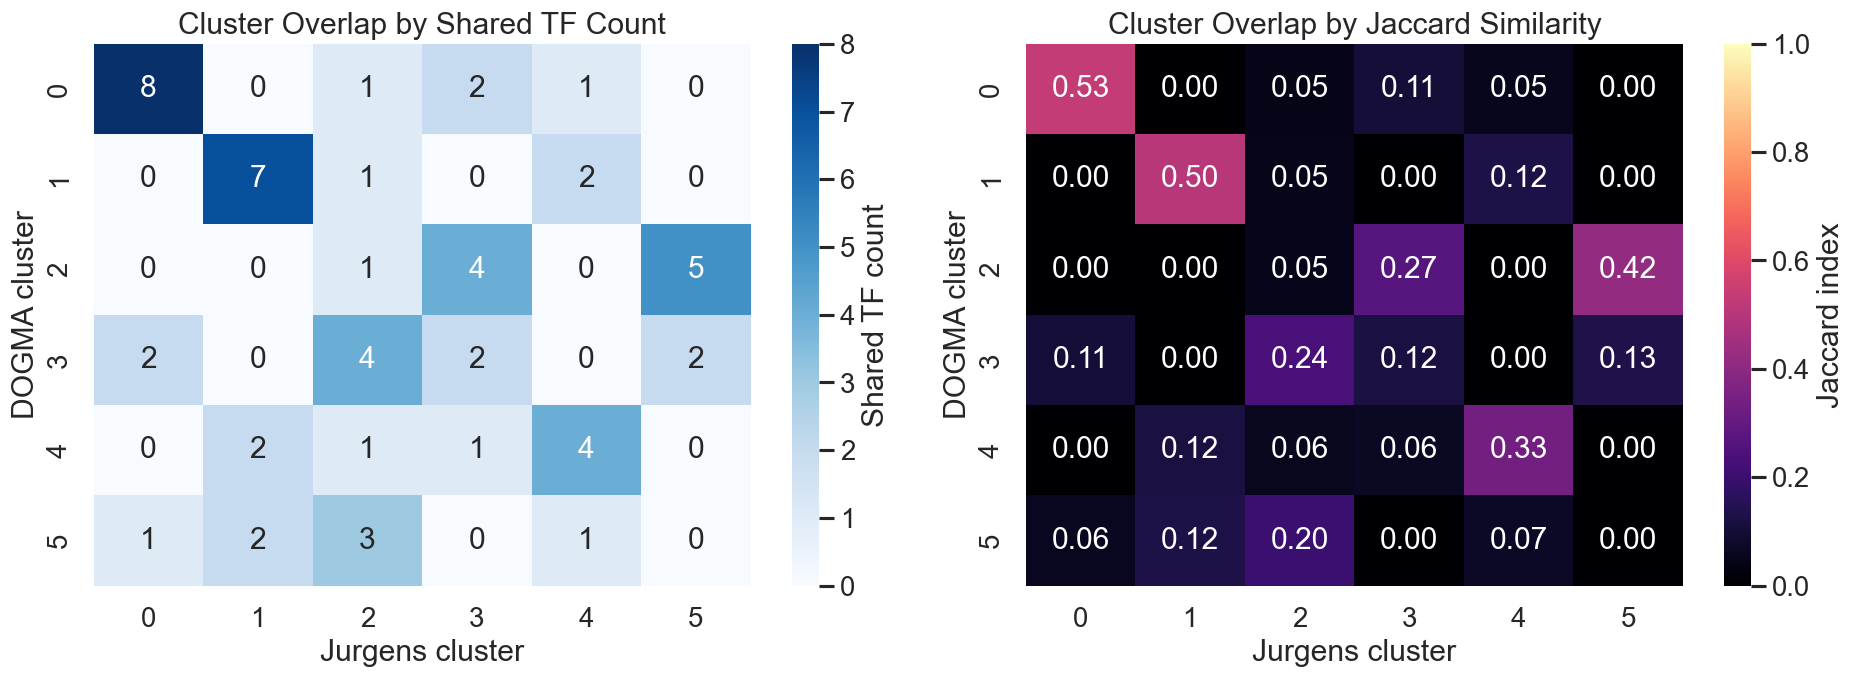

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(shared_count_matrix, annot=True, fmt='.0f', cmap='Blues', cbar_kws={'label': 'Shared TF count'}, ax=axes[0])
axes[0].set_title('Cluster Overlap by Shared TF Count')
axes[0].set_xlabel('Jurgens cluster')
axes[0].set_ylabel('DOGMA cluster')

sns.heatmap(jaccard_matrix, annot=True, fmt='.2f', cmap='magma', vmin=0, vmax=1, cbar_kws={'label': 'Jaccard index'}, ax=axes[1])
axes[1].set_title('Cluster Overlap by Jaccard Similarity')
axes[1].set_xlabel('Jurgens cluster')
axes[1].set_ylabel('DOGMA cluster')

plt.tight_layout()
plt.show()

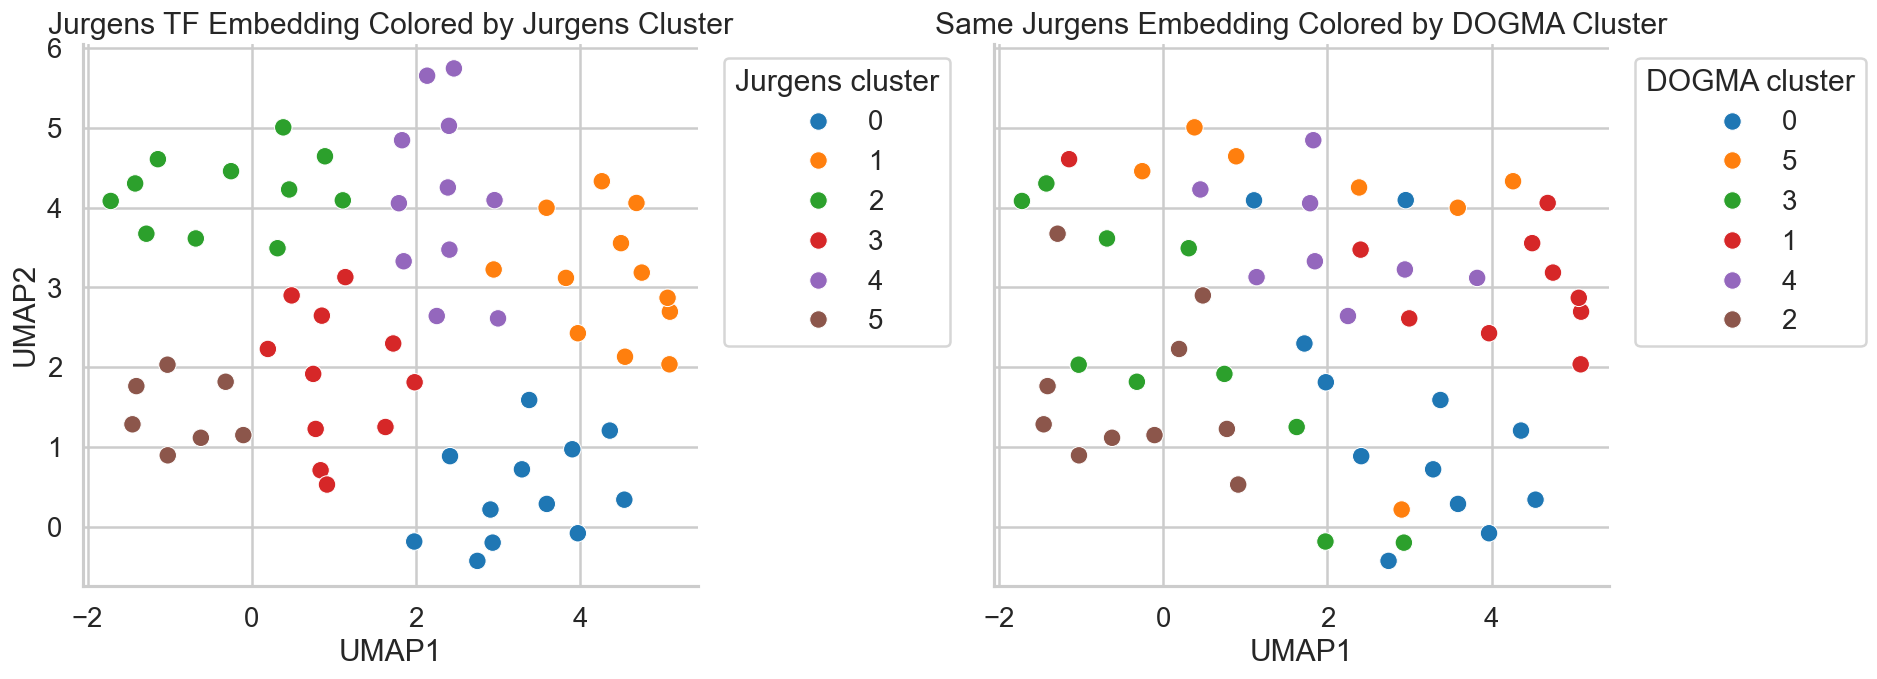

In [7]:
dogma_cluster_lookup = dogma_assign.set_index('TF')['cluster'].to_dict()
jurgens_plot = jurgens_assign.copy()
jurgens_plot['dogma_cluster'] = jurgens_plot['TF'].map(dogma_cluster_lookup)
jurgens_plot['shared_with_dogma'] = jurgens_plot['TF'].isin(shared_tfs)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)

sns.scatterplot(
    data=jurgens_plot,
    x='UMAP1',
    y='UMAP2',
    hue='cluster',
    palette='tab10',
    s=110,
    edgecolor='white',
    linewidth=0.6,
    ax=axes[0],
)
axes[0].set_title('Jurgens TF Embedding Colored by Jurgens Cluster')
axes[0].legend(title='Jurgens cluster', bbox_to_anchor=(1.02, 1), loc='upper left')

shared_overlay = jurgens_plot[jurgens_plot['shared_with_dogma']].copy()
shared_overlay['dogma_cluster_label'] = shared_overlay['dogma_cluster'].astype('Int64').astype(str)

sns.scatterplot(
    data=shared_overlay,
    x='UMAP1',
    y='UMAP2',
    hue='dogma_cluster_label',
    palette='tab10',
    s=110,
    edgecolor='white',
    linewidth=0.6,
    ax=axes[1],
)
axes[1].set_title('Same Jurgens Embedding Colored by DOGMA Cluster')
axes[1].legend(title='DOGMA cluster', bbox_to_anchor=(1.02, 1), loc='upper left')

for ax in axes:
    ax.set_xlabel('UMAP1')
    ax.set_ylabel('UMAP2')

plt.tight_layout()
plt.show()

## TF-Pair Correlation Concordance

In [8]:
pair_comparison = (
    dogma_pairs[['pair_key', 'pair_label', 'correlation', 'rank']]
    .rename(columns={'correlation': 'dogma_corr', 'rank': 'dogma_rank'})
    .merge(
        jurgens_pairs[['pair_key', 'pair_label', 'correlation', 'rank']]
        .rename(columns={'correlation': 'jurgens_corr', 'rank': 'jurgens_rank'}),
        on='pair_key',
        how='inner',
        suffixes=('_dogma', '_jurgens'),
    )
)

pair_comparison['pair_label'] = pair_comparison['pair_label_dogma']
pair_comparison['abs_diff'] = (pair_comparison['dogma_corr'] - pair_comparison['jurgens_corr']).abs()
pair_comparison['mean_corr'] = pair_comparison[['dogma_corr', 'jurgens_corr']].mean(axis=1)
pair_comparison['rank_shift'] = (pair_comparison['dogma_rank'] - pair_comparison['jurgens_rank']).abs()

pearson_r = pair_comparison['dogma_corr'].corr(pair_comparison['jurgens_corr'], method='pearson')
spearman_r = pair_comparison['dogma_corr'].corr(pair_comparison['jurgens_corr'], method='spearman')

pair_comparison.sort_values('dogma_rank').head()

,pair_key,pair_label_dogma,dogma_corr,dogma_rank,pair_label_jurgens,jurgens_corr,jurgens_rank,pair_label,abs_diff,mean_corr,rank_shift
0,IKZF3__NFATC3,IKZF3 / NFATC3,0.903030,13,IKZF3 / NFATC3,0.903030,13,IKZF3 / NFATC3,0.000000,0.903030,0
1,CREM__NR4A3,CREM / NR4A3,0.866667,28,CREM / NR4A3,0.878788,17,CREM / NR4A3,0.012121,0.872727,11
2,NR4A2__NR4A3,NR4A2 / NR4A3,0.866667,32,NR4A2 / NR4A3,0.927273,6,NR4A2 / NR4A3,0.060606,0.896970,26
3,AHR__RBPJ,AHR / RBPJ,0.854545,36,AHR / RBPJ,0.769697,71,AHR / RBPJ,0.084848,0.812121,35
4,HAVCR2__IKZF3,HAVCR2 / IKZF3,0.854545,41,HAVCR2 / IKZF3,0.963636,2,HAVCR2 / IKZF3,0.109091,0.909091,39


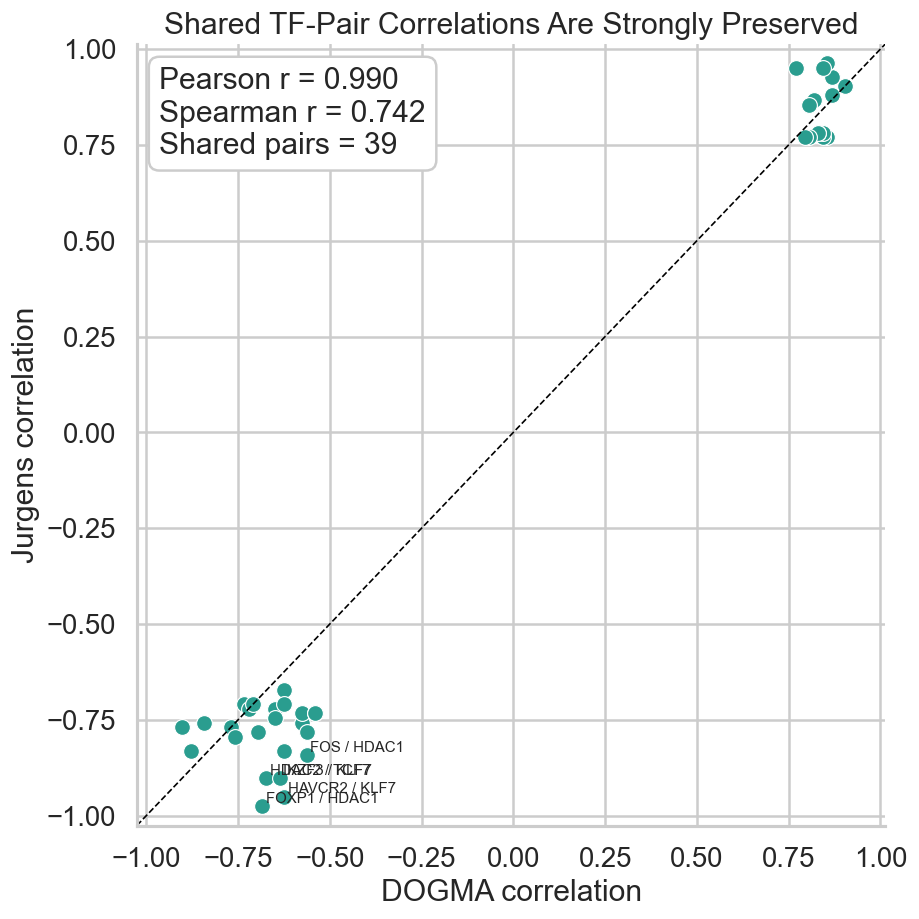

In [9]:
fig, ax = plt.subplots(figsize=(8, 8))

sns.scatterplot(
    data=pair_comparison,
    x='dogma_corr',
    y='jurgens_corr',
    s=90,
    color='#2A9D8F',
    edgecolor='white',
    linewidth=0.7,
    ax=ax,
)

lims = [
    min(pair_comparison['dogma_corr'].min(), pair_comparison['jurgens_corr'].min()) - 0.05,
    max(pair_comparison['dogma_corr'].max(), pair_comparison['jurgens_corr'].max()) + 0.05,
]
ax.plot(lims, lims, linestyle='--', color='black', linewidth=1)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('DOGMA correlation')
ax.set_ylabel('Jurgens correlation')
ax.set_title('Shared TF-Pair Correlations Are Strongly Preserved')
ax.text(
    0.03,
    0.97,
    f'Pearson r = {pearson_r:.3f}\nSpearman r = {spearman_r:.3f}\nShared pairs = {len(pair_comparison)}',
    transform=ax.transAxes,
    ha='left',
    va='top',
    bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='0.8'),
)

for _, row in pair_comparison.nlargest(5, 'abs_diff').iterrows():
    ax.text(row['dogma_corr'] + 0.01, row['jurgens_corr'] + 0.01, row['pair_label'], fontsize=9)

plt.tight_layout()
plt.show()

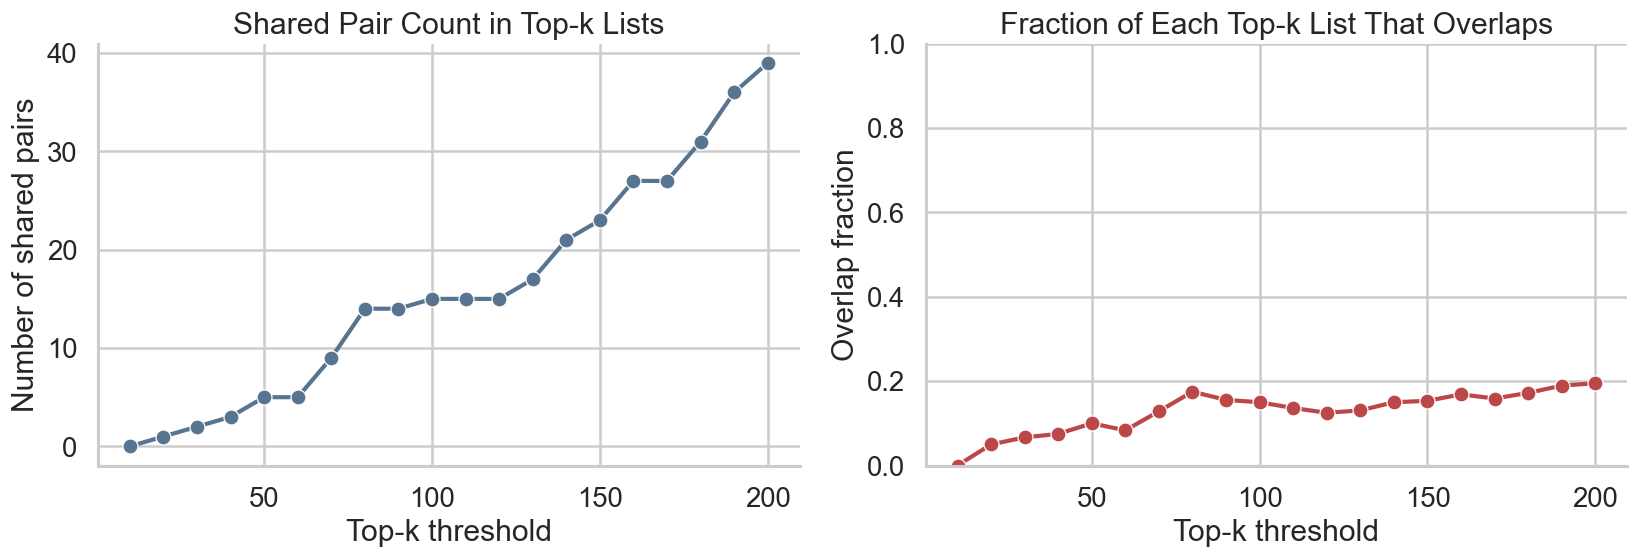

,top_k,shared_pairs,overlap_fraction
0,10,0,0.000000
1,20,1,0.050000
2,30,2,0.066667
3,40,3,0.075000
4,50,5,0.100000


In [10]:
top_k_values = list(range(10, min(len(dogma_pairs), len(jurgens_pairs)) + 1, 10))
rank_overlap = []
for k in top_k_values:
    dogma_top = set(dogma_pairs.nsmallest(k, 'rank')['pair_key'])
    jurgens_top = set(jurgens_pairs.nsmallest(k, 'rank')['pair_key'])
    overlap = len(dogma_top & jurgens_top)
    rank_overlap.append({
        'top_k': k,
        'shared_pairs': overlap,
        'overlap_fraction': overlap / k,
    })
rank_overlap = pd.DataFrame(rank_overlap)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=rank_overlap, x='top_k', y='shared_pairs', marker='o', linewidth=2.5, color='#577590', ax=axes[0])
axes[0].set_title('Shared Pair Count in Top-k Lists')
axes[0].set_xlabel('Top-k threshold')
axes[0].set_ylabel('Number of shared pairs')

sns.lineplot(data=rank_overlap, x='top_k', y='overlap_fraction', marker='o', linewidth=2.5, color='#BC4749', ax=axes[1])
axes[1].set_title('Fraction of Each Top-k List That Overlaps')
axes[1].set_xlabel('Top-k threshold')
axes[1].set_ylabel('Overlap fraction')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

rank_overlap.head()

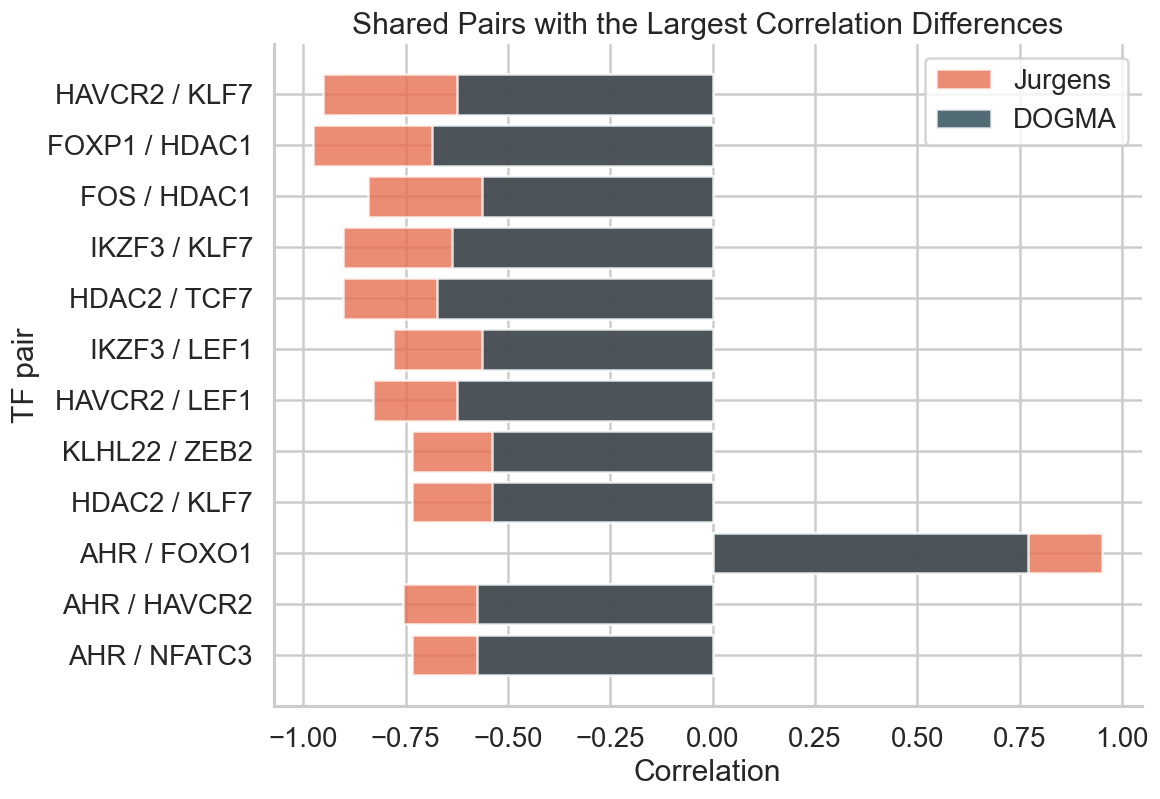

,pair_label,dogma_corr,jurgens_corr,abs_diff,dogma_rank,jurgens_rank
34,AHR / NFATC3,-0.575758,-0.733333,0.157576,174,159
33,AHR / HAVCR2,-0.575758,-0.757576,0.181818,173,149
14,AHR / FOXO1,0.769697,0.951515,0.181818,94,3
37,HDAC2 / KLF7,-0.539394,-0.733333,0.193939,197,163
38,KLHL22 / ZEB2,-0.539394,-0.733333,0.193939,198,167
32,HAVCR2 / LEF1,-0.624242,-0.830303,0.206061,158,122
36,IKZF3 / LEF1,-0.563636,-0.781818,0.218182,187,134
25,HDAC2 / TCF7,-0.672727,-0.903030,0.230303,134,103
28,IKZF3 / KLF7,-0.636364,-0.903030,0.266667,150,104
35,FOS / HDAC1,-0.563636,-0.842424,0.278788,185,114


In [11]:
largest_disagreements = pair_comparison.nlargest(12, 'abs_diff').copy()
largest_disagreements = largest_disagreements.sort_values('abs_diff', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(largest_disagreements['pair_label'], largest_disagreements['jurgens_corr'], color='#E76F51', alpha=0.8, label='Jurgens')
ax.barh(largest_disagreements['pair_label'], largest_disagreements['dogma_corr'], color='#264653', alpha=0.8, label='DOGMA')
ax.set_title('Shared Pairs with the Largest Correlation Differences')
ax.set_xlabel('Correlation')
ax.set_ylabel('TF pair')
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

largest_disagreements[['pair_label', 'dogma_corr', 'jurgens_corr', 'abs_diff', 'dogma_rank', 'jurgens_rank']]

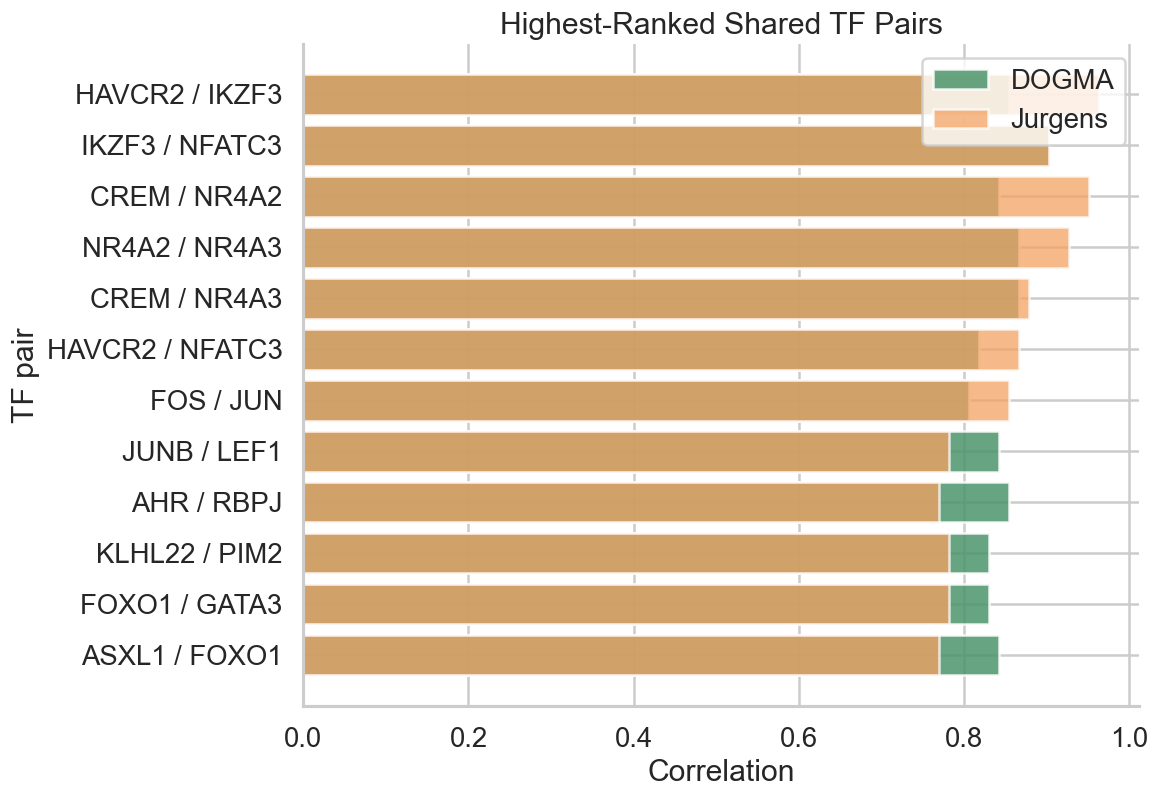

,pair_label,dogma_corr,jurgens_corr,dogma_rank,jurgens_rank,abs_diff
0,IKZF3 / NFATC3,0.903030,0.903030,13,13,0.000000
1,CREM / NR4A3,0.866667,0.878788,28,17,0.012121
2,NR4A2 / NR4A3,0.866667,0.927273,32,6,0.060606
3,AHR / RBPJ,0.854545,0.769697,36,71,0.084848
4,HAVCR2 / IKZF3,0.854545,0.963636,41,2,0.109091
5,ASXL1 / FOXO1,0.842424,0.769697,44,73,0.072727
6,CREM / NR4A2,0.842424,0.951515,46,4,0.109091
7,JUNB / LEF1,0.842424,0.781818,50,68,0.060606
8,FOXO1 / GATA3,0.830303,0.781818,56,65,0.048485
9,KLHL22 / PIM2,0.830303,0.781818,60,69,0.048485


In [12]:
top_shared_pairs = pair_comparison.nsmallest(12, 'dogma_rank').copy()
top_shared_pairs = top_shared_pairs.sort_values('mean_corr', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_shared_pairs['pair_label'], top_shared_pairs['dogma_corr'], color='#4C956C', alpha=0.85, label='DOGMA')
ax.barh(top_shared_pairs['pair_label'], top_shared_pairs['jurgens_corr'], color='#F4A261', alpha=0.75, label='Jurgens')
ax.set_title('Highest-Ranked Shared TF Pairs')
ax.set_xlabel('Correlation')
ax.set_ylabel('TF pair')
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

pair_comparison.sort_values(['dogma_rank', 'jurgens_rank']).head(15)[
    ['pair_label', 'dogma_corr', 'jurgens_corr', 'dogma_rank', 'jurgens_rank', 'abs_diff']
]

## Quick Takeaways

In [13]:
best_cluster_row = cluster_overlap.sort_values(['jaccard', 'shared_tfs'], ascending=False).iloc[0]
summary_lines = [
    f"Shared TF coverage is high: {len(shared_tfs)} of {dogma_assign.TF.nunique()} DOGMA TFs are also present in Jurgens.",
    f"The strongest cluster correspondence is DOGMA cluster {int(best_cluster_row['dogma_cluster'])} vs Jurgens cluster {int(best_cluster_row['jurgens_cluster'])} with Jaccard = {best_cluster_row['jaccard']:.2f} and {int(best_cluster_row['shared_tfs'])} shared TFs.",
    f"Shared top TF-pair correlations are highly concordant (Pearson r = {pearson_r:.3f}, Spearman r = {spearman_r:.3f}).",
    f"Only {len(shared_pairs)} TF pairs overlap between the two top-200 lists, so the datasets agree more strongly on effect size for shared hits than on the exact composition of the ranked lists.",
]

for line in summary_lines:
    print('-', line)

- Shared TF coverage is high: 57 of 57 DOGMA TFs are also present in Jurgens.
- The strongest cluster correspondence is DOGMA cluster 0 vs Jurgens cluster 0 with Jaccard = 0.53 and 8 shared TFs.
- Shared top TF-pair correlations are highly concordant (Pearson r = 0.990, Spearman r = 0.742).
- Only 39 TF pairs overlap between the two top-200 lists, so the datasets agree more strongly on effect size for shared hits than on the exact composition of the ranked lists.
